# Part 2

The goal in Part 2 is to build a generative model — one that writes new captions rather than copying existing ones. The architecture is a CNN + LSTM encoder-decoder: the frozen ResNet-50 from Part 1 encodes each image into a 2,048-dimensional feature vector, a Dense projection maps that vector into the LSTM decoder's initial hidden and cell states, and the LSTM then generates a caption word by word.

Unlike the KNN retrieval baseline in Part 1, which could only reproduce captions it had already seen, this model learns a language model conditioned on image features and can compose novel sentences.

Why this model?
- We learned about using a modified version of an RNN layer — the Long Short Term Memory (LSTM) layer — in class. 
- RNNs are used for processing sequential data, such as the text data like we're doing here with image captioning. So I knew I wanted to incorporate at least one type of RNN into this project. Unlike ANN and CNN, RNN layers run as many times as they are time points in the sequence instance. So if we perform word-level tokenization on our training captions, the number of tokens will be the number of time steps that the LSTM runs. Then the parameters of the recurrent part are updated with respect to all tokens. 
- And since vanishing gradients can occur in regular RNNs (the gradients shrink exponentially during backpropagation if they're multiplied by a recurrent weight matrix slightly smaller than 1), which essentially just means that the earlier time steps will have zero gradients and thus not be able to affect the parameter updates of the recurrent layer, using an LSTM layer should fix this. The hidden state for long-term memory will carry information from earlier time steps and update its parameters accordingly, while the hidden state for short-term memory will carry information from the more recent time steps and update its parameters accordingly. This means the network will take both hidden states into account at each time step to calculate the next hidden state, and the model itself can determine the amount of information taken from each hidden state at each step. 
- So in this part, we'll be using a CNN + LSTM encoder-decoder — reusing the same ResNet-50 extractor from Part 1 to make the two parts comparable, and to see whether a generative LSTM decoder produces better or worse BLEU scores than the retrieval baseline. 

What we did:
1. Same `75% train / 12.5% val / 12.5% test` split as Part 1.
2. Build a vocabulary from training captions: lowercase and tokenize, drop words that appear fewer than 2 times, and add four special tokens — `<PAD>`, `<START>`, `<END>`, and `<UNK>`.
3. Reuse the same frozen ResNet-50 extractor from Part 1 (global average pooling -> 2,048-dim). Also extract and cache features for the validation split.
4. Convert each caption to a padded integer sequence, then create teacher-forcing pairs: the decoder input is `[<START>, w1, ..., w_{n-1}]` and the target is `[w1, ..., wn, <END>]`.
5. Define the encoder-decoder: a Dense layer projects the 2,048-dim image feature to `LSTM_UNITS` dimensions and uses the result as both the initial hidden state h0 and cell state c0 of the LSTM decoder, which predicts one word per time step with `return_sequences = True`.
6. Train with a masked sparse cross-entropy loss (ignoring `<PAD>` positions) and early stopping on validation loss. Cache trained weights so the cell is skipped on re-run.
7. Implement batched greedy decoding — at each step the model scores the next token for all test images in one forward pass, appending the argmax token to each active sequence until `<END>` or `max_len`.
8. Compute corpus-level BLEU-1 through BLEU-4 on the test set using the same setup as Part 1 so the scores are directly comparable.
9. Visualize a sample of test image predictions alongside their reference captions.

Import all the libraries and tools needed below.

In [1]:
import os
import certifi
os.environ['SSL_CERT_FILE'] = certifi.where()

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import tensorflow as tf
from keras.applications import ResNet50
from keras.applications.resnet50 import preprocess_input
from keras.models import Model
from keras.layers import Input, Dense, Embedding, LSTM, Dropout
import nltk

nltk.download('punkt', quiet = True)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

Set the paths to the dataset. The `archive/` folder is expected to sit alongside this notebook.

In [2]:
ARCHIVE_DIR  = os.path.join(os.getcwd(), 'archive')
CAPTIONS_CSV = os.path.join(ARCHIVE_DIR, 'captions.txt')
IMAGES_DIR   = os.path.join(ARCHIVE_DIR, 'Images')
CACHE_DIR    = os.path.join(os.getcwd(), 'cache')

os.makedirs(CACHE_DIR, exist_ok = True)

### 1)

Load the captions file and reproduce the same train/val/test split as Part 1 (75% / 12.5% / 12.5%, seed 42). Splitting at the image level ensures all five captions for a given image stay in the same partition — no caption leaks across splits.

The validation set is used here (unlike Part 1) because training the LSTM decoder requires monitoring held-out loss to decide when to stop.

In [3]:
df = pd.read_csv(CAPTIONS_CSV)
df.columns = df.columns.str.strip()   # strip white space in front of 'image'

# tokenize and lowercase — same helper as Part 1
def tokenize(text):
    return re.findall(r'[a-z]+', text.lower())

df['tokens'] = df['caption'].apply(tokenize)

# ensure reproducibility
all_images = sorted(df['image'].unique())
random.seed(42)
random.shuffle(all_images)

# train/val/test split
n       = len(all_images)
n_train = int(0.75  * n)
n_val   = int(0.125 * n)

train_imgs = set(all_images[:n_train])
val_imgs   = set(all_images[n_train : n_train + n_val])
test_imgs  = set(all_images[n_train + n_val:])

train_list = sorted(train_imgs)
val_list   = sorted(val_imgs)
test_list  = sorted(test_imgs)

print('Train images :', len(train_list))
print('Val images   :', len(val_imgs))
print('Test images  :', len(test_list))

Train images : 6068
Val images   : 1011
Test images  : 1012


Visualize three images to get a feel for them. 

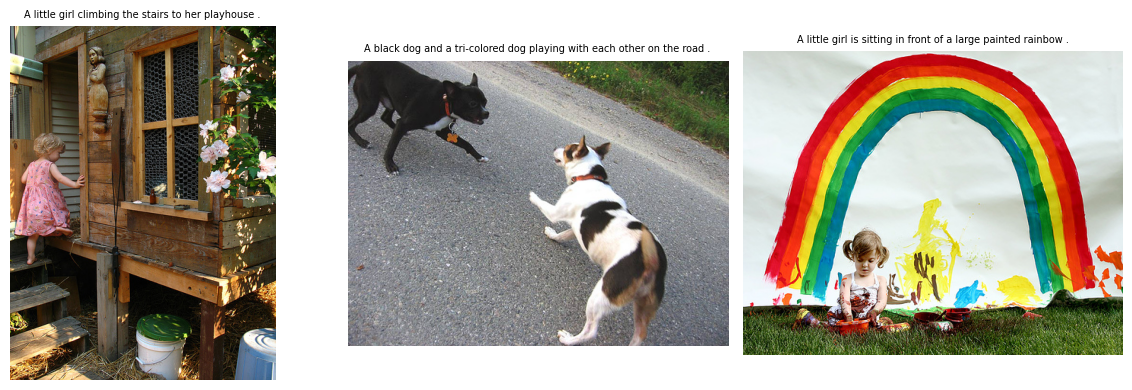

In [4]:
train_captions = (
    df[df['image'].isin(train_imgs)]
    .groupby('image')['caption']
    .apply(list)
    .to_dict()
)

sample_fnames = train_list[:3] # first 3 training images

fig, axes = plt.subplots(1, 3, figsize = (12, 4))

for ax, fname in zip(axes, sample_fnames):
    caption = random.choice(train_captions[fname]) # randomly select one of the 5 captions
    ax.imshow(mpimg.imread(os.path.join(IMAGES_DIR, fname)))
    ax.set_title(caption, fontsize = 7, wrap = True)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 2)

Build the vocabulary from training captions only. (Don't touch val or test captions to prevent data leakage.)

Add 4 special tokens:
- `<PAD>` (index 0) — pads shorter sequences to a fixed length. Making it index 0 is important, since keras's embedding layer's `mask_zero = True` flag tells the LSTM to skip any position where the input token is 0. 
- `<START>` (index 1) — prepended to every decoder input sequence to signal the beginning of generation.
- `<END>` (index 2) — appended to every target sequence; the decoder learns to emit this token when it's done.
- `<UNK>` (index 3) — replaces any word that appears fewer than `MIN_FREQ = 2` times in training. And also handles any words that appear in val/test but not the training vocabulary by mapping it to this catch-all token. 

Reasoning:
- For the LSTM to work, we have to tokenize every word into a number.
- We'll start by counting and making a dictionary of words and their frequencies in the training dataset. 
- Next, we'll create the four special tokens, then prepend them to the alphabetically-sorted list of words kept in the training dataset. 
- We also create `word2idx` and `idx2word` which do exactly as they sound. 
- Filtering rare words reduces the output space the softmax must cover and prevents the model from wasting capacity on words it has seen too few times to generalize. We're using threshold of 2 since it's standard for small captioning datasets.
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding

In [5]:
MIN_FREQ = 2   # drop words appearing fewer than two times in training

# Make a dictionary of word and a count of their frequencies across all training captions
word_freq = {}
for fname in train_list:
    for tokens in df[df['image'] == fname]['tokens']:
        for w in tokens:
            word_freq[w] = word_freq.get(w, 0) + 1 # increment count, initializing to 0 if word is new

# Special tokens must occupy the first four indices
PAD_TOKEN   = '<PAD>'    # index 0
START_TOKEN = '<START>'  # index 1
END_TOKEN   = '<END>'    # index 2
UNK_TOKEN   = '<UNK>'    # index 3
SPECIAL     = [PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN]

# Build vocab: special tokens first, then filtered words in sorted order
# filter through dictionary of word frequencies and retains only words that appear two or more times
    # sort them alphabetically
    # append the alphabetized words directly after the 4 special tokens
vocab    = SPECIAL + sorted(w for w, c in word_freq.items() if c >= MIN_FREQ)
# compile a dictionary converting string words into integer indices
word2idx = {w: i for i, w in enumerate(vocab)}
# reverses the key-value pairs of word2idx, to get back each human-readable word from its index
idx2word = {i: w for w, i in word2idx.items()}

VOCAB_SIZE = len(vocab)
# get integer position of each special token
IDX_PAD    = word2idx[PAD_TOKEN]    # 0
IDX_START  = word2idx[START_TOKEN]  # 1
IDX_END    = word2idx[END_TOKEN]    # 2
IDX_UNK    = word2idx[UNK_TOKEN]    # 3

print('Full training vocabulary  :', len(word_freq)) # total number of unique words
print('Kept after MIN_FREQ filter:', sum(1 for c in word_freq.values() if c >= MIN_FREQ))
print('Final vocabulary size     :', VOCAB_SIZE, '(including 4 special tokens)')

Full training vocabulary  : 7468
Kept after MIN_FREQ filter: 4502
Final vocabulary size     : 4506 (including 4 special tokens)


In comparison, note that this is what we got from the EDA, when we looked at the entire dataset: 
Total tokens (with repeats) : 437,429
Vocabulary size             : 8,441
Hapax legomena (count = 1)  : 3,310

So what we got here, with just the training dataset, makes sense — we dropped 7468-4502 = 2966 words that appeared less than two times. Also, 2,966 is smaller than the 3,310 words we would have dropped if we instead used the whole dataset. 

### 3)

Build the same ResNet-50 feature extractor used in Part 1. `include_top = False` drops the classification head, and `pooling = 'avg'` applies global average pooling so each image produces one 2,048-dimensional vector. Setting `encoder.trainable = False` freezes all ResNet-50 weights — the encoder is never updated during decoder training.

Reasoning:
- We're reusing the same pretrained extractor from Part 1 so that the image representations fed to the LSTM are identical to those used in the baseline. This makes the comparison fair — we know that any BLEU improvement will come from the generative decoder, not from a different visual representation.
- Freezing the encoder also cuts training time dramatically and prevents overfitting, since the encoder already learned general visual features from ImageNet.
- https://keras.io/api/applications/resnet/resnet_models/#resnet50-function

In [6]:
encoder = ResNet50(
    weights      = 'imagenet', # load pretrained ImageNet weights
    include_top  = False, # drop the classification head
    pooling      = 'avg' # global average pooling -> 2,048-dim vector per image
)
encoder.trainable = False # freeze all ResNet-50 weights

def load_image(filename):
    path = os.path.join(IMAGES_DIR, filename)
    img  = Image.open(path).convert('RGB').resize((224, 224)) # ResNet-50 expects 224x224
    arr  = np.array(img, dtype = 'float32')
    arr  = np.expand_dims(arr, axis = 0) # add batch dimension -> (1, 224, 224, 3)
    return preprocess_input(arr) # preprocessing per ResNet-50 expectations (RGB to BGR channel flip + per-channel ImageNet mean subtraction)

print('Encoder output shape per image:', encoder.output_shape)

2026-06-10 17:08:25.920213: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-10 17:08:25.920237: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-10 17:08:25.920241: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-10 17:08:25.920254: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-10 17:08:25.920263: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Encoder output shape per image: (None, 2048)


### 4)

Extract the 2,048-dimensional feature vector for every image in all three splits and save the results to disk. If a cache file already exists (including the ones written by Part 1), it is loaded directly to avoid redundant computation.

The validation features are new here — Part 1 did not need them because there were no hyperparameters to tune for a KNN retrieval model.

Reasoning
- Extracting features means running every image through ResNet-50 one by one, which takes a while, and those computed vectors would also disappear from memory whenever we close then reopen this ipynb. 
- So the cache is just two files saved to disk so recomputing isn't necessary and the network doesn't have to rerun the extraction loop.
- https://keras.io/api/models/model_training_apis/#predict-method 

In [7]:
def extract_features(img_list, cache_path):
    # if cache files already exist on disk, load them:
    if os.path.exists(cache_path):
        feats = np.load(cache_path)
        print(f'Loaded from cache : {cache_path}')
        return feats
    
    # if cache files don't already exist on disk:
    # preallocate a matrix of zeros — one row per image, 2048 columns 
    feats = np.zeros((len(img_list), 2048), dtype = 'float32')

    # runs image through ResNet-50, returns a (1, 2048 array)
    for i, fname in enumerate(img_list): # for position i and filename 
        feats[i] = encoder.predict(load_image(fname), verbose = 0)
        if (i + 1) % 500 == 0: # print progress
            print(f'  {i + 1} / {len(img_list)} done')

    # write array to disk
    np.save(cache_path, feats)
    print(f'Extracted and cached: {cache_path}')
    return feats

train_features = extract_features(train_list, os.path.join(CACHE_DIR, 'train_features.npy'))
val_features   = extract_features(val_list,   os.path.join(CACHE_DIR, 'val_features.npy'))
test_features  = extract_features(test_list,  os.path.join(CACHE_DIR, 'test_features.npy'))

print('Train feature matrix shape:', train_features.shape)
print('Val feature matrix shape  :', val_features.shape)
print('Test feature matrix shape :', test_features.shape)

Loaded from cache : /Users/valeriechu/Desktop/flickr8k-image-captioning/cache/train_features.npy
Loaded from cache : /Users/valeriechu/Desktop/flickr8k-image-captioning/cache/val_features.npy
Loaded from cache : /Users/valeriechu/Desktop/flickr8k-image-captioning/cache/test_features.npy
Train feature matrix shape: (6068, 2048)
Val feature matrix shape  : (1011, 2048)
Test feature matrix shape : (1012, 2048)


### 5)

Convert every caption into a padded integer sequence and assemble teacher-forcing training pairs.

The maximum sequence length `MAX_LEN` is computed over training captions only (including the `<START>` and `<END>` boundary tokens). All sequences are zero-padded to this length with `<PAD>` (index 0).

Teacher forcing creates supervised targets for the LSTM: instead of feeding the LSTM's own previous prediction at each step, we feed the true previous word from the ground-truth caption. This means:
- **Decoder input**: `[<START>, w1, w2, ..., w_{n-1}]` — the caption with the last token dropped. Aka our `X_cap`.
- **Target**: `[w1, w2, ..., wn, <END>]` — the same caption shifted left by one, with the first token dropped. Aka our `y_cap`.

Each image has five captions, so the training set contains `5 x n_train_images` sequence pairs, each paired with its image feature vector.

Reasoning:
- Teacher forcing prevents an off-track model for getting punished for every subsequent word it generates. To make an analogy, it kind of works as such: We're taking a test. On this test, the second problem draws on the answer of the first, the third problem draws on the answer of the second, and so on. (In our context, this refers to predicting the subsequent word based on the previous word). Teacher forcing is when, in between giving our first answer and putting down our second answer, we get to reference the answer key — but *only* the answer key to the first problem. (In our context, this answer key is the ground truth.) 
- So essentially, teacher forcing stabilizes training by providing a consistent learning signal and avoiding compounding prediction errors early in training when the model makes many mistakes.
- Using the helper function `encode_caption` and the max function, we will find the length of the longest caption in the training set (`MAX_LEN`). The captions are encoded temporarily just to measure their length and not stored. 
- Then, with the helper function `make_sequences`, we will encode every caption again and actually build the three parallel arrays that the model will train on. At each time step, the LSTM will take two inputs: the image feature (`X_img`) and the caption tokens to decode from (`X_cap`) — and predict the next token at each step, `y_cap`. Since we're training the LSTM from scratch, we need labeled pairs — input sequence and corresponding target sequence — for every caption that the model is supposed to predict. Padding all sequences to the same length (`MAX_LEN`) allows them to be stacked into a single NumPy array and fed to the model in batches. 
- https://medium.com/data-science/what-is-teacher-forcing-3da6217fed1c
- https://machinelearningmastery.com/teacher-forcing-for-recurrent-neural-networks/

In [ ]:
def encode_caption(tokens):
    # convert token list to integer sequence, bookended with <START> and <END>
    return (
        [IDX_START]
        # look up word's index; returns index of unknown (3) if unknown
        + [word2idx.get(w, IDX_UNK) for w in tokens] 
        + [IDX_END]
    )

# compute max sequence length from training captions only
MAX_LEN = max(
    len(encode_caption(tokens))
    for fname in train_list # every training image
    for tokens in df[df['image'] == fname]['tokens'] # every image's five captions
)

# teacher forcing means input and target are one token shorter than the full sequence
# see make_sequence below, where we dropped either first/last token
SEQ_LEN = MAX_LEN - 1 

print('Max full sequence length (including <START> and <END>):', MAX_LEN)
print('Decoder input / target length                         :', SEQ_LEN)

Max full sequence length (including <START> and <END>): 38
Decoder input / target length                         : 37


In [9]:
def make_sequences(img_list, img_feats):
    # return parallel arrays: image features, decoder inputs, decoder targets
    X_img, X_cap, y_cap = [], [], []
    for i, fname in enumerate(img_list):
        for tokens in df[df['image'] == fname]['tokens']:
            seq = encode_caption(tokens)
            # pad to MAX_LEN with zeros (<PAD>)
            seq = seq + [IDX_PAD] * (MAX_LEN - len(seq))
            X_img.append(img_feats[i])
            X_cap.append(seq[:-1]) # drop last token -> decoder input  [<START>, w1, ..., w_{n-1}]
            y_cap.append(seq[1:]) # drop first token -> decoder target [w1, ..., wn, <END>]
    return (
        np.array(X_img, dtype = 'float32'),
        np.array(X_cap, dtype = 'int32'),
        np.array(y_cap, dtype = 'int32')
    )

X_img_train, X_cap_train, y_cap_train = make_sequences(train_list, train_features)
X_img_val, X_cap_val, y_cap_val = make_sequences(val_list, val_features)

print('Training samples   :', len(X_img_train))
print('Validation samples :', len(X_img_val))
print('Sequence length    :', X_cap_train.shape[1])
print('Example input  [0] :', X_cap_train[0, :8])
print('Example target [0] :', y_cap_train[0, :8])

Training samples   : 30340
Validation samples : 5055
Sequence length    : 37
Example input  [0] : [   1    4  732 1947    4 2810 1164 2002]
Example target [0] : [   4  732 1947    4 2810 1164 2002  782]


### 6)

Define the encoder-decoder model using the Keras Functional API (as introduced in Exercise Set 17).

The model has two input branches that are merged inside the LSTM:

**Image encoder branch**
The 2,048-dim ResNet-50 feature is projected down to `LSTM_UNITS` dimensions by a Dense layer with ReLU activation. The result is used as both the initial hidden state h0 and the initial cell state c0 of the LSTM. This is how visual information is injected into the language model: the LSTM "starts" in a state that encodes what the image looks like, then generates words from there.

**Caption decoder branch**
The decoder input sequence (integers of length `SEQ_LEN`) is passed through an Embedding layer that maps each token index to a dense `EMBED_DIM`-dimensional vector. The Embedding is trained from scratch alongside the rest of the decoder. `mask_zero = True` causes the Embedding layer to propagate a mask through the LSTM: padded positions (index 0) do not influence the hidden state.

**LSTM decoder**
The LSTM processes the embedded caption tokens one step at a time, conditioned on the image-initialized hidden state, and outputs a hidden vector at every time step (`return_sequences = True`). This allows the final Dense layer to predict the next word at every position simultaneously during training.

**Output layer**
A Dense layer with softmax over `VOCAB_SIZE` converts each hidden vector to a probability distribution over the vocabulary. The argmax at position k is the model's prediction for the token at position k+1.

Reasoning:
- ResNet-50 is the encoder — it processes raw image pixels to extract high-level visual features. 
- LSTM is the decoder — it takes the visual features extracted by ResNet50 and processes them over time to model sequences, thus predicting our image captions. 
- Since we have two inputs (image feature and caption tokens), we'll use Functional API instead of Sequential. 
- `Model` needs inputs `img_input` and `cap_input`, and output `word_output` — which is obtained when we run the image (`img_drop`) and caption (`cap_drop`) through the LSTM decoder, aka the initial hidden state and initial cell state of the LSTM are from the output of the encoder.
- https://keras.io/guides/functional_api/
- https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM
- https://keras.io/api/layers/core_layers/embedding/
- https://www.tensorflow.org/api_docs/python/tf/keras/Model

In [ ]:
EMBED_DIM  = 256   # dimension of word embeddings
LSTM_UNITS = 256   # LSTM hidden state size (matches image projection output size)
DROPOUT    = 0.3   # dropout rate applied after image projection, embedding, and lstm

# Image encoder branch — gets img_input and also img_drop, which is the projected image feature
# use functional API pattern bc we have two inputs — image feature and caption tokens
img_input = Input(shape = (2048,), name = 'image_input')
# need to compress image into LSTM_UNITS's 256 dims 
img_proj = Dense(LSTM_UNITS, activation = 'relu', name = 'image_projection')(img_input)
img_drop = Dropout(DROPOUT, name = 'image_dropout')(img_proj)

# Caption decoder branch — gets cap_input and also cap_drop, which is the word embeddings
#   (cap_drop is a (batch, SEQ_LEN, EMBED_DIM) tensor where each token has been converted to a 256-dim vector with some randomly zeroed out during training)
cap_input = Input(shape = (SEQ_LEN,), name = 'caption_input') # returns (batch, SEQ_LEN)
# a lookup table with shape VOCAB_SIZE (1 row per word) x EMBED_DIM (each row is a 256-dim learned vector)
# return a vector for each time step (batch, SEQ_LEN, EMBED_DIM)
cap_embed = Embedding(
    VOCAB_SIZE, EMBED_DIM,
    mask_zero = True, # mask out padding values (tell the LSTM to skip positions where the token is <PAD> (aka index 0))
    name = 'word_embedding'
)(cap_input)

cap_drop = Dropout(DROPOUT, name = 'embedding_dropout')(cap_embed)

# LSTM decoder initialized with the projected image feature
lstm_out = LSTM(
    LSTM_UNITS,
    return_sequences = True, # output a hidden vector at every time step
    name = 'lstm_decoder'
)(cap_drop, initial_state = [img_drop, img_drop]) # h0 = c0 = projected image feature

lstm_drop = Dropout(DROPOUT, name = 'lstm_dropout')(lstm_out)

# Output: next-word distribution at every time step
word_output = Dense(VOCAB_SIZE, activation = 'softmax', name = 'word_output')(lstm_drop)

model = Model(inputs = [img_input, cap_input], outputs = word_output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ caption_input       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 37, 256)   │  1,153,536 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_projection    │ (None, 256)       │    524,544 │ image_input[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 37, 256)   │          0 │ word_embedding[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dropout       │ (None, 256)       │          0 │ image_projection… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_decoder (LSTM) │ (None, 37, 256)   │    525,312 │ embedding_dropou… │
│                     │                   │            │ image_dropout[0]… │
│                     │                   │            │ image_dropout[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dropout        │ (None, 37, 256)   │          0 │ lstm_decoder[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_output (Dense) │ (None, 37, 4506)  │  1,158,042 │ lstm_dropout[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,361,434 (12.82 MB)

 Trainable params: 3,361,434 (12.82 MB)

 Non-trainable params: 0 (0.00 B)

### 7)

Train the encoder-decoder model. If a cached weights file already exists from a previous run, the weights are loaded directly and training is skipped.

**Masked loss**
Standard sparse categorical cross-entropy would average the loss over all `SEQ_LEN` positions, including the `<PAD>` positions that carry no information. Instead, we define a custom masked loss that computes the per-position loss, zeroes out the padding positions, and averages only over the real tokens. This gives a more accurate gradient signal.

**Early stopping**
Training monitors `val_loss` and halts if it does not improve for `patience = 5` consecutive epochs, then restores the weights from the best epoch. This prevents the decoder from overfitting to the training captions.

Reasoning:
- We're making a custom loss to deal with padding, using `sparse_categorical_crossentropy` (instead of `categorical_crossentropy`) because it expects `y_true` to be raw integer token indices — indeed, what `y_cap` contains — instead of thousands of one-hot encoded vectors. 
- Then after computing the loss, we apply the mask (1s and 0s from `tf.not_equal`) to zero out padding positions — since without masking the loss, padding positions would dilute the gradient with near-zero contributions, slowing convergence. 
- https://www.tensorflow.org/api_docs/python/tf/keras/losses/sparse_categorical_crossentropy
- https://www.tensorflow.org/api_docs/python/tf/math/reduce_sum
- https://keras.io/api/callbacks/early_stopping/

In [11]:
def masked_sparse_ce(y_true, y_pred):
    # sparse cross-entropy ignoring <PAD> positions (index 0)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred) # (batch, SEQ_LEN)
    mask = tf.cast(tf.not_equal(y_true, IDX_PAD), dtype = loss.dtype) # 1 at real tokens, 0 at <PAD>
    loss = loss * mask # zero out any penalty earned on padding tokens
    return tf.reduce_sum(loss) / tf.reduce_sum(mask) # mean over real tokens only, aka
                                                        # total losses / total number of real words

model.compile(
    optimizer = 'adam',
    loss = masked_sparse_ce
)

Epoch 1/20


2026-06-10 17:08:38.986068: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


475/475 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - loss: 4.5113 - val_loss: 3.8316
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - loss: 3.7254 - val_loss: 3.5421
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 3.4902 - val_loss: 3.4002
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - loss: 3.3533 - val_loss: 3.3201
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 3.2570 - val_loss: 3.2624
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 3.1797 - val_loss: 3.2222
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - loss: 3.1170 - val_loss: 3.1918
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 3.0628 - val_loss: 3.1696
Epoch 9/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 3.0154 - val_loss: 3.1517
Epoch 10/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 2.9721 - val_loss: 3.1404
Epoch 11/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 2.9338 - val_loss: 3.1293
Epoch 12/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 

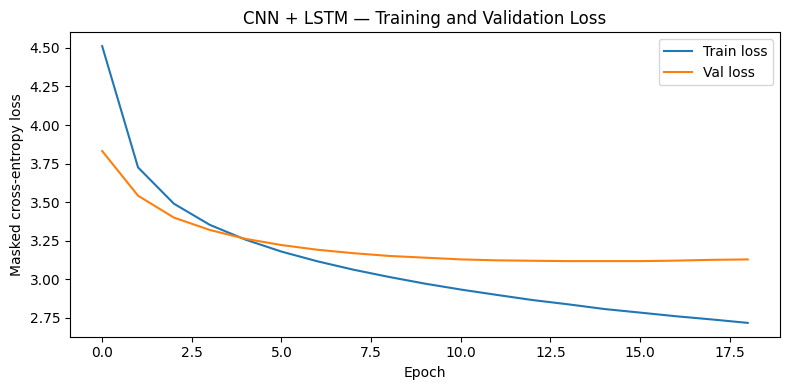

In [12]:
WEIGHTS_PATH = os.path.join(CACHE_DIR, 'cnn_lstm_weights.weights.h5')

if os.path.exists(WEIGHTS_PATH):
    model.load_weights(WEIGHTS_PATH)
    print('Loaded weights from cache — skipping training.')
else:
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 5, # stop after 5 epochs with no improvement
        restore_best_weights = True # revert to the best checkpoint
    )

    history = model.fit(
        [X_img_train, X_cap_train],
        y_cap_train,
        validation_data = ([X_img_val, X_cap_val], y_cap_val),
        batch_size = 64,
        epochs = 20,
        callbacks = [early_stop]
    )

    model.save_weights(WEIGHTS_PATH)
    print('Training complete. Weights saved to cache.')

    # plot training curve
    plt.figure(figsize = (8, 4))
    plt.plot(history.history['loss'],     label = 'Train loss')
    plt.plot(history.history['val_loss'], label = 'Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Masked cross-entropy loss')
    plt.title('CNN + LSTM — Training and Validation Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

### 8)

Implement batched greedy decoding for inference.

We previously used teacher forcing for training, but at inference time, we no longer have ground-truth tokens to feed the decoder — which means the model has to generate an image caption from its own predictions (which are fed back in as inputs step by step). Greedy search is a simple decoding method that selects the word with the highest probability as its next word. And we'll be batching the decoding runs (putting all val/test images through one forward pass per step instead of doing them separately.)

The decoding loop runs over all test images at once:
1. Initialize every sequence to `[<START>, <PAD>, <PAD>, ...]`.
2. At each step k, run a single forward pass over all test images. The model output at position k is the predicted distribution over next tokens; take the argmax.
3. For sequences that have not yet produced `<END>`, write the argmax token into position k+1.
4. Mark a sequence as done when it emits `<END>` or when position k reaches `SEQ_LEN - 1`.
5. Repeat until every sequence is done.

This produces at most `SEQ_LEN - 1` forward passes total — far fewer than one pass per image per step. (ex. 36 instead of 1012x36)

The mask propagated by `mask_zero = True` in the Embedding layer ensures that `<PAD>` positions (which have not been written yet) do not influence the LSTM's state at earlier positions, so the model output at position k correctly depends only on tokens at positions 0 through k.

Reasoning:
- Greedy decoding (argmax at each step) is the simplest inference strategy. Beam search would improve quality by keeping the top-k hypotheses at each step but adds complexity, so that would be more of a next step. And while sampling produces more diverse and creative outputs, since we're doing image captioning instead of creative writing, and since it makes BLEU scores non-reproducible, we won't be doing sampling here either. Right now, greedy decoding makes the most sense as the starting point for an initial generative model.
- Batching all test images into a single forward pass per step is much more efficient than generating one image at a time, since it lets us make use of parallel processing. 
- https://huggingface.co/blog/how-to-generate
- https://medium.com/@ghayas.7214/image-captioning-with-cnn-lstm-why-beam-search-beats-greedy-decoding-e2ddf18c7c85

In [ ]:
def generate_captions_batch(img_feats, max_steps = None):
    # Greedy-decode captions for a batch of images

    # by default, max_steps is the max number of tokens we can generate (-1 bc of <START>) 
    if max_steps is None:
        max_steps = SEQ_LEN - 1

    # set up
    N = len(img_feats)
    seqs = np.full((N, SEQ_LEN), IDX_PAD, dtype = 'int32') # matrix filled with all <PAD>
    seqs[:, 0] = IDX_START # position 0 is always <START>
    done = np.zeros(N, dtype = bool) # create a boolean array, one False per image,
                                        # so that we can track which sequences finished and subsequently skip them

    for step in range(max_steps):
        # one forward pass over the entire batch
            # on all image features and current state of all sequences
        preds = model.predict(
            [img_feats, seqs],
            verbose = 0,
            batch_size = 64
        ) # (N, SEQ_LEN, VOCAB_SIZE) 
            # a probability distribution over  
            # the vocabulary at every position for every image
        
        # slice out one time step for all images (one index for SEQ_LEN), to get (N, VOCAB_SIZE)
        #   then return index of highest-prob word for each image, (N, )
        next_tokens = np.argmax(preds[:, step, :], axis = 1) # argmax at current position

        # for each image
        for i in range(N):
            if done[i]: # skip if already finished
                continue
            if next_tokens[i] == IDX_END: # flag if predicted token is <END>
                done[i] = True # sequence is complete
            else: 
                seqs[i, step + 1] = next_tokens[i]   # append predicted token

        if done.all():
            break   # all sequences have finished early

    # convert integer sequences back to word lists, stripping <START>, <END>, <PAD>
    captions = []
    # for each image
    for i in range(N):
        words = []
        for j in range(1, SEQ_LEN): # skip position 0 (<START>)
            idx = seqs[i, j]
            if idx in (IDX_PAD, IDX_END): # stop if we hit <PAD> or <END> 
                break
            # otherwise, look up the word for each index, defaulting to <UNK> if unknown
            words.append(idx2word.get(idx, UNK_TOKEN))
        captions.append(words) # and append the completed word list to captions before moving to image i+1
    return captions

### 9)

Generate captions for every test image and compute corpus-level BLEU-1 through BLEU-4 using the same setup as Part 1 so the scores are directly comparable.

Each test image has five reference captions. BLEU-1 measures unigram overlap; BLEU-4 requires matching 4-gram sequences and is therefore much stricter. The same `SmoothingFunction().method1` is applied to BLEU-2 through BLEU-4 to handle cases where a higher-order n-gram precision is zero.

Reasoning:
- Computing the same BLEU metrics against the same test split as Part 1 isolates the effect of the model architecture. Any change in score reflects the generative decoder, not a different evaluation setup.
- https://www.nltk.org/api/nltk.translate.bleu_score.html

In [ ]:
# map each test image name to its five reference captions (same as Part 1)
test_captions = (
    df[df['image'].isin(test_imgs)]
    .groupby('image')['caption']
    .apply(list)
    .to_dict()
)

# generate captions for all test images in one batched call
predicted_tokens = generate_captions_batch(test_features)

# build references and hypotheses in the format corpus_bleu expects
references = [] # list of lists-of-lists (5 tokenized refs per image)
hypotheses = [] # list of tokenized predictions
# unlike part 1, no need to track the neighbor (training image) each caption was stolen from
#   (since part 2 generates captions, so there's no source image to track)

for i, fname in enumerate(test_list):
    refs = [tokenize(c) for c in test_captions[fname]] # loops through and tokenizes each test image's 5 test captions
    hyp  = predicted_tokens[i]                            # generated caption token list
    references.append(refs)
    hypotheses.append(hyp)

print('Inference complete.')
print('Example prediction    :', ' '.join(hypotheses[0]))
print('Example reference [0] :', ' '.join(references[0][0]))

Inference complete.
Example prediction    : a man in a black shirt is standing on a sidewalk with a man in a blue shirt and a black and white shirt
Example reference [0] : a man lays on a bench while his dog sits by him


In [15]:
smoother = SmoothingFunction().method1 # add epsilon counts to precision with 0 counts

bleu1 = corpus_bleu(references, hypotheses, weights = (1, 0, 0, 0))
bleu2 = corpus_bleu(references, hypotheses, weights = (0.5, 0.5, 0, 0),         smoothing_function = smoother)
bleu3 = corpus_bleu(references, hypotheses, weights = (1/3, 1/3, 1/3, 0),       smoothing_function = smoother)
bleu4 = corpus_bleu(references, hypotheses, weights = (0.25, 0.25, 0.25, 0.25), smoothing_function = smoother)

print(f'BLEU-1 : {bleu1:.4f}')
print(f'BLEU-2 : {bleu2:.4f}')
print(f'BLEU-3 : {bleu3:.4f}')
print(f'BLEU-4 : {bleu4:.4f}')

BLEU-1 : 0.3976
BLEU-2 : 0.2208
BLEU-3 : 0.1179
BLEU-4 : 0.0698


### 10)

Visualize a sample of test images alongside their generated caption and one reference caption. This provides a qualitative check on where the model succeeds and where it fails — complementing the aggregate BLEU scores with concrete examples.

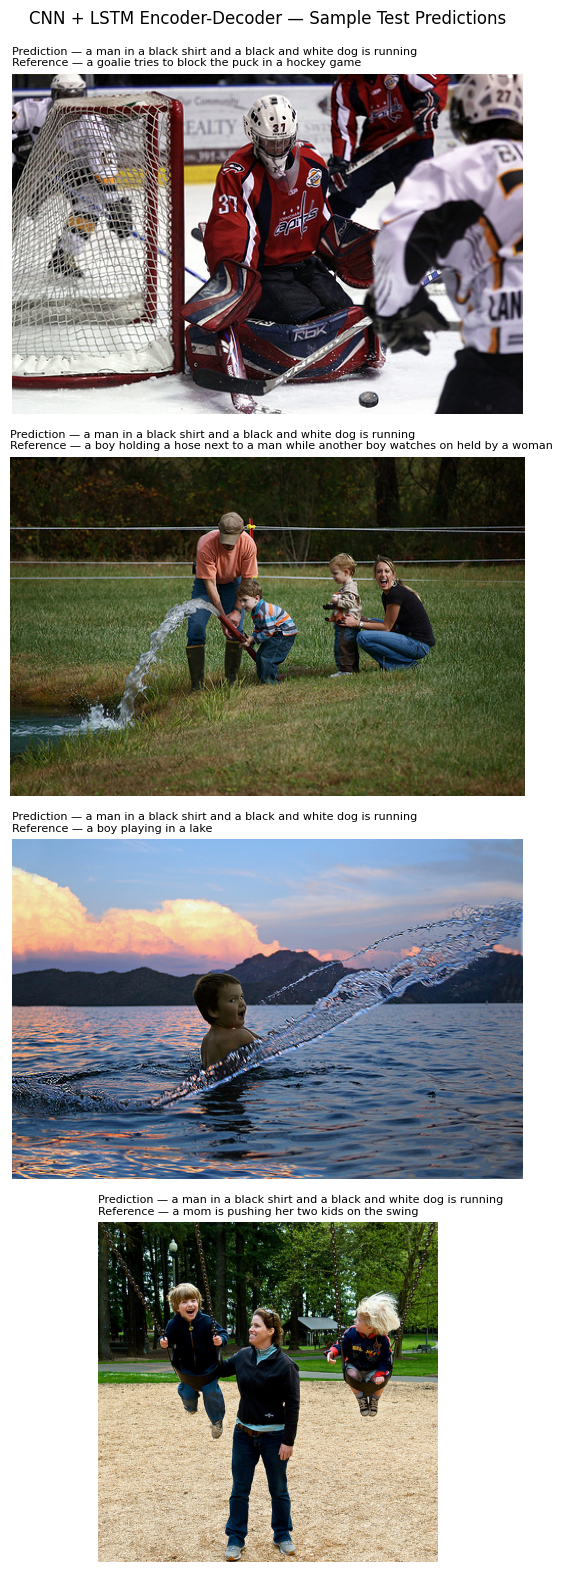

In [ ]:
n_show = 4
random.seed(42)
sample_i = random.sample(range(len(test_list)), n_show) # get n_show number of randomly sampled indices to extract images to plot

fig, axes = plt.subplots(n_show, 1, figsize = (10, 4 * n_show))

for row, i in enumerate(sample_i):
    fname = test_list[i]
    pred_text = ' '.join(hypotheses[i]) if hypotheses[i] else '(empty)' # guards against if generate_captions_batch returns an empty list
    ref_text = ' '.join(references[i][0])

    axes[row].imshow(mpimg.imread(os.path.join(IMAGES_DIR, fname)))
    axes[row].axis('off')
    axes[row].set_title(
        f'Prediction — {pred_text}\nReference — {ref_text}',
        fontsize = 8,
        loc = 'left'
    )

plt.suptitle('CNN + LSTM Encoder-Decoder — Sample Test Predictions\n', fontsize = 12)
plt.tight_layout()
plt.show()

For the retrieval baseline, the BLEU scores were:
BLEU-1 : 0.4257
BLEU-2 : 0.2407
BLEU-3 : 0.1353
BLEU-4 : 0.0764, 

whereas for the CNN + LSTM encoder-decoder, the BLEU scores were:
BLEU-1 : 0.3976
BLEU-2 : 0.2208
BLEU-3 : 0.1179
BLEU-4 : 0.0698

This is surprisingly high, considering that all test-set predictions were the exact same caption. The scores for the retrieval baseline and for the CNN + LSTM encoder-decoder were also surprisingly close to each other. 

I suspect this is because the image only conditions the LSTM once, at initialization — the 2,048-dim image feature was used to initialize the hidden and cell state, but then afterwards, we updated the hidden state entirely through just the word sequence. (Because LSTMs work such that each step mixes the previous hidden state with the current input token (which, during generation, is the token predicted by the previous step) to produce the new hidden state.) So then the image signal got further diluted as the model predicted each subsequent word. 

During greedy search, in which the model selected the word with the highest probability as the image caption's next word, the LSTM learned the specific caption structure that most reliably minimized cross-entropy loss across the training set — and produced the same high-probability caption regardless of the image it was given to predict an image caption for. Which made it such that tuning the hyperparameters like dropout, patience, epochs, and batch_size wouldn't really change the model performance, since the problem was structural. 